|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>ANNs<h1>|
|<h2>Lecture:</h2>|<h1><b>Multilayer ANNs<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
%matplotlib widget 

# import libraries
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

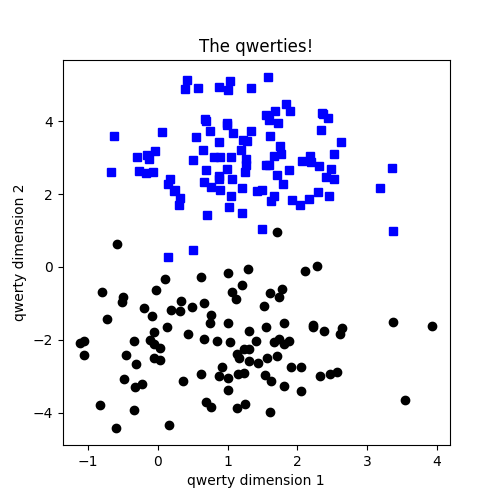

In [2]:
# create data

nPerClust = 100
blur = 1

A = [  1,  3 ]
B = [  1, -2 ]

# generate data
a = [ A[0]+np.random.randn(nPerClust)*blur , A[1]+np.random.randn(nPerClust)*blur ]
b = [ B[0]+np.random.randn(nPerClust)*blur , B[1]+np.random.randn(nPerClust)*blur ]

# true labels
labels_np = np.vstack((np.zeros((nPerClust,1)),np.ones((nPerClust,1))))

# concatanate into a matrix
data_np = np.hstack((a,b)).T

# convert to a pytorch tensor
data = torch.tensor(data_np).float()
labels = torch.tensor(labels_np).float()

# show the data
fig = plt.figure(figsize=(5,5))
plt.plot(data[np.where(labels==0)[0],0],data[np.where(labels==0)[0],1],'bs')
plt.plot(data[np.where(labels==1)[0],0],data[np.where(labels==1)[0],1],'ko')
plt.title('The qwerties!')
plt.xlabel('qwerty dimension 1')
plt.ylabel('qwerty dimension 2')
plt.show()

# Functions to build and train the model

In [3]:
def createANNmodel(learningRate):

  # model architecture
  ANNclassify = nn.Sequential(
      nn.Linear(2,16),  # input layer
      nn.ReLU(),        # activation unit
      nn.Linear(16,32),  # hidden layer
      nn.ReLU(),        # activation unit
      nn.Linear(32,1),  # hidden layer
      nn.ReLU(),        # activation unit
      nn.Linear(1,1),   # output unit
      # nn.Sigmoid(),     # final activation unit
        )

  # loss function
  lossfun = nn.BCEWithLogitsLoss() # BCELoss, but better to use BCEWithLogitsLoss

  # optimizer
  optimizer = torch.optim.SGD(ANNclassify.parameters(),lr=learningRate)

  # model output
  return ANNclassify,lossfun,optimizer

In [4]:
# a function that trains the model

# a fixed parameter
numepochs = 1000

def trainTheModel(ANNmodel):

  # initialize losses
  losses = torch.zeros(numepochs)

  # loop over epochs
  for epochi in range(numepochs):

    # forward pass
    yHat = ANNmodel(data)

    # compute loss
    loss = lossfun(yHat,labels)
    losses[epochi] = loss

    # backprop
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()



  # final forward pass
  predictions = ANNmodel(data)

  # compute the predictions and report accuracy
  # NOTE: Wasn't this ">0" previously?!?!
  totalacc = 100*torch.mean(((predictions>0) == labels).float())

  return losses,predictions,totalacc

# Test the new code by running it once

Final accuracy: 98%


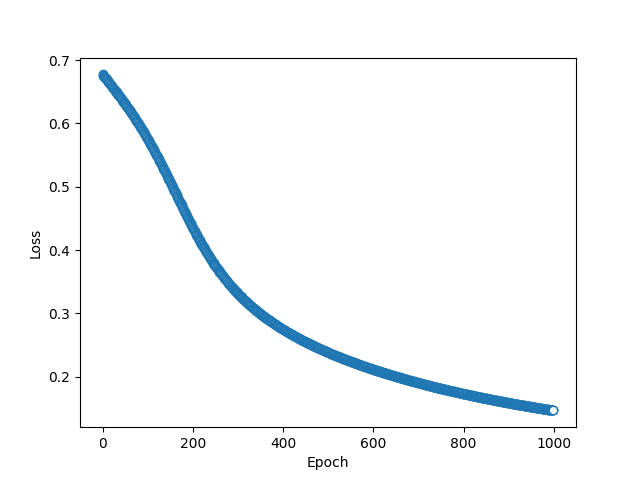

In [5]:
# create everything
ANNclassify,lossfun,optimizer = createANNmodel(.01)

# run it
losses,predictions,totalacc = trainTheModel(ANNclassify)

# report accuracy
print('Final accuracy: %g%%' %totalacc)


# show the losses
fig = plt.figure()
plt.plot(losses.detach(),'o',markerfacecolor='w',linewidth=.1)
plt.xlabel('Epoch'), plt.ylabel('Loss')
plt.show()

# Now for the real test (varying learning rates)

In [6]:
# learning rates
learningrates = np.linspace(.001,.1,50)

# initialize
accByLR = []
allLosses = np.zeros((len(learningrates),numepochs))


# the loop
for i,lr in enumerate(learningrates):

  # create and run the model
  ANNclassify,lossfun,optimizer = createANNmodel(lr)
  losses,predictions,totalacc = trainTheModel(ANNclassify)

  # store the results
  accByLR.append(totalacc)
  allLosses[i,:] = losses.detach()


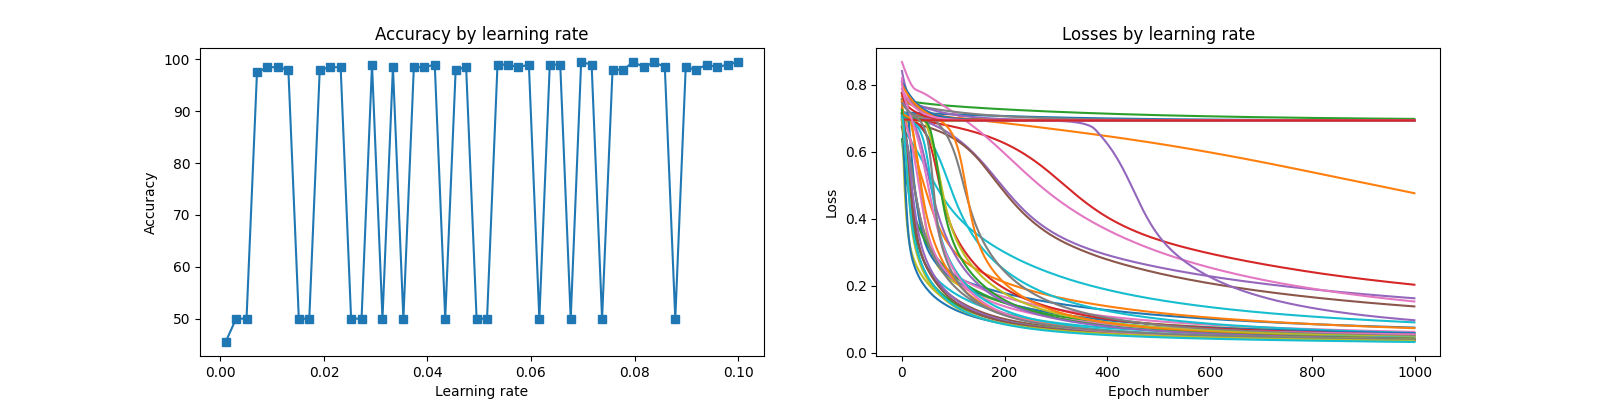

In [7]:
# plot the results
fig,ax = plt.subplots(1,2,figsize=(16,4))

ax[0].plot(learningrates,accByLR,'s-')
ax[0].set_xlabel('Learning rate')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Accuracy by learning rate')

ax[1].plot(allLosses.T)
ax[1].set_title('Losses by learning rate')
ax[1].set_xlabel('Epoch number')
ax[1].set_ylabel('Loss')
plt.show()

In [8]:
accByLR

[tensor(45.5000),
 tensor(50.),
 tensor(50.),
 tensor(97.5000),
 tensor(98.5000),
 tensor(98.5000),
 tensor(98.),
 tensor(50.),
 tensor(50.),
 tensor(98.),
 tensor(98.5000),
 tensor(98.5000),
 tensor(50.),
 tensor(50.),
 tensor(99.),
 tensor(50.),
 tensor(98.5000),
 tensor(50.),
 tensor(98.5000),
 tensor(98.5000),
 tensor(99.),
 tensor(50.),
 tensor(98.),
 tensor(98.5000),
 tensor(50.),
 tensor(50.),
 tensor(99.),
 tensor(99.),
 tensor(98.5000),
 tensor(99.),
 tensor(50.),
 tensor(99.),
 tensor(99.),
 tensor(50.),
 tensor(99.5000),
 tensor(99.),
 tensor(50.),
 tensor(98.),
 tensor(98.),
 tensor(99.5000),
 tensor(98.5000),
 tensor(99.5000),
 tensor(98.5000),
 tensor(50.),
 tensor(98.5000),
 tensor(98.),
 tensor(99.),
 tensor(98.5000),
 tensor(99.),
 tensor(99.5000)]

In [9]:
sum(torch.tensor(accByLR)>70)/len(accByLR)

tensor(0.6800)

# Additional explorations

In [ ]:
# 1) The code creates a model with 16 hidden units. Notice where the two "16"s appear when constructing the model.
#    Recreate the model using 32 hidden units. Does that help with the issue of models getting stuck in local minima?
#
# No.
#
# 2) Adjust the code to create two hidden layers. The first hidden layer should have 16 hidden units and the second
#    hidden layer shuold have 32 units. What needs to change in the code to make the numbers match to prevent coding errors?
#
# The consequiteve layers shlall have matching input/output dimensions.
# 